# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: **Borbála Balás**
* Username: **bbalas**
* Student s-number: **S6449549**
* Group (AS1, etc.): **AS3**

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

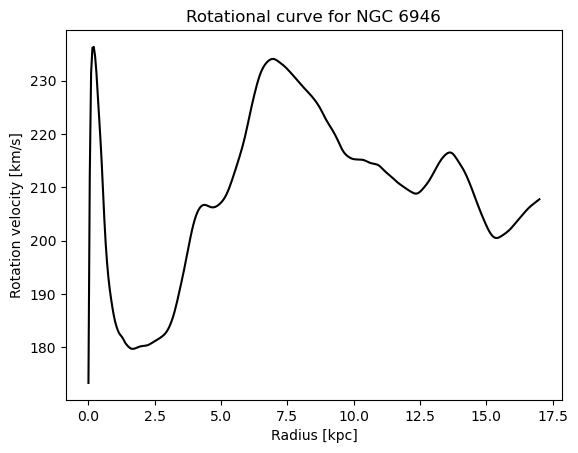

In [2]:
import numpy as np
from scipy.constants import G, parsec
import matplotlib.pyplot as plt

M = (2*10**10) * (1.988*10**30)
file = np.loadtxt('rotcur.dat.txt', comments = '#')
radius = file[:,0]
velocity = file[:,1]

plt.plot(radius,velocity,color='black')
plt.title('Rotational curve for NGC 6946')
plt.xlabel('Radius [kpc]')
plt.ylabel('Rotation velocity [km/s]')
plt.show()


# assuming that the total mass comes from the black hole in the middle
curve = []
for r in radius:
    if r != 0:
        curve.append(np.sqrt(G*M/(r*1000*parsec))/1000)
    else:
        curve.append(0)
        
curve = np.array(curve)

np.savetxt('keplerian_curve.txt',curve)

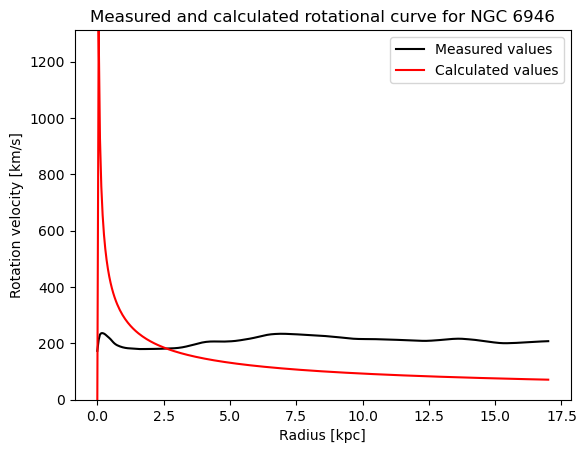

The rotation is not Keplerian rotation


In [3]:
keplerian = np.loadtxt('keplerian_curve.txt')
plt.ylim(0,np.max(keplerian))

plt.plot(radius,velocity,color='black',label ='Measured values')
plt.plot(radius,keplerian,color='r',label ='Calculated values')
plt.title('Measured and calculated rotational curve for NGC 6946')
plt.xlabel('Radius [kpc]')
plt.ylabel('Rotation velocity [km/s]')
plt.legend()
plt.show()

print('The rotation is not Keplerian rotation')

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    The Keplerian curve is plotted incorrectly, we want you to make sure the horizontal bar (by approximation) is not shown.  <b>[0.5pt deducted from total points]</b>

In [4]:
# Leave unaltered
totalpoints += 4
currentpoints += 3.5

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

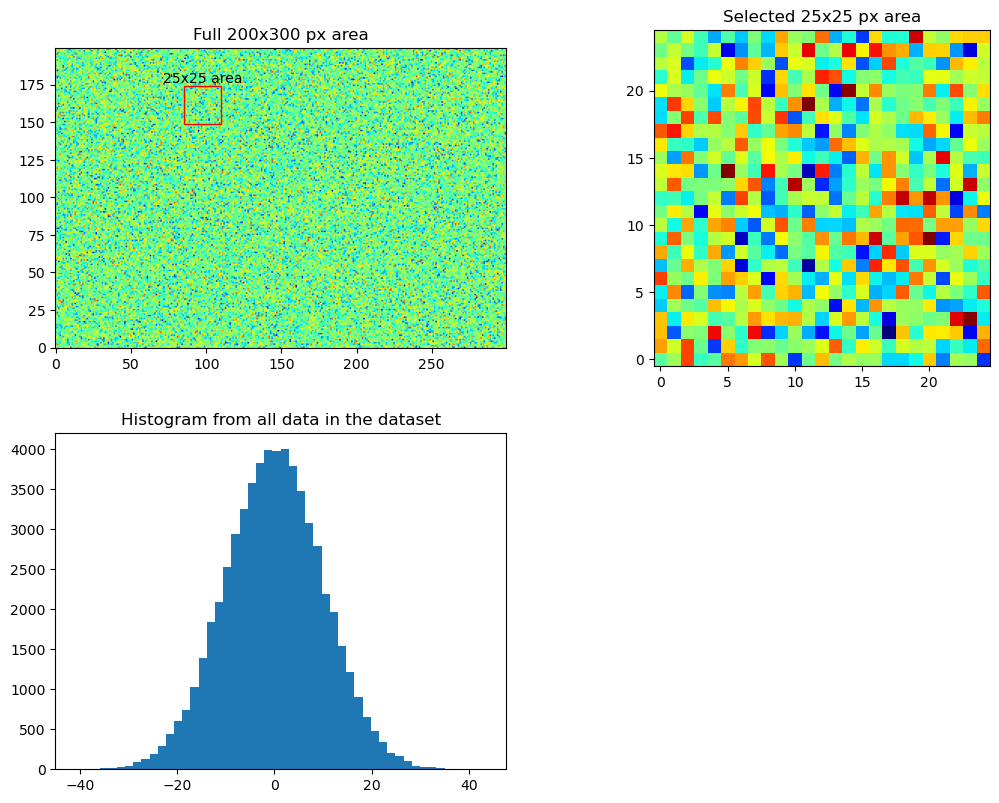

The mean of the selected 25x25 area is 0.0961 compared to the full data's -0.0407
The standard deviation of the selected 25x25 area is 10.2270 compared to the full data's 10.0276


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


data = []
for i in range(200):
    data.append(np.random.normal(0,10,300))
data = np.array(data)

size = 25
chosen = [np.random.randint(0,300-size),np.random.randint(0,200-size)]

area = data[chosen[1]:chosen[1]+size]
area = area[:,chosen[0]:chosen[0]+size]

fig = plt.figure(figsize = [12.8, 9.6])

full = fig.add_subplot(2,2,1)
full.imshow(data,cmap='jet',origin = 'lower')
full.add_patch(Rectangle((chosen[0],chosen[1]),size,size, fill=False, color = 'r'))
full.text(chosen[0]+size/2,chosen[1]+size if chosen[1]<200-1.5*size else chosen[1]-size,f'{size}x{size} area', horizontalalignment='center',verticalalignment='bottom',fontsize=10)
full.set_title(f'Full 200x300 px area')

sliced = fig.add_subplot(2,2,2)
sliced.imshow(area,cmap='jet',origin='lower')
sliced.set_title(f'Selected {size}x{size} px area')

histo = fig.add_subplot(2,2,3)
data = data.flatten()
histo.hist(data, bins = 50) # gaussian distribution histogram with mean around 0 and std around 10
histo.set_title('Histogram from all data in the dataset')
plt.show()

print(f'The mean of the selected {size}x{size} area is {np.mean(area):.4f} compared to the full data\'s {np.mean(data):.4f}')
print(f'The standard deviation of the selected {size}x{size} area is {np.std(area):.4f} compared to the full data\'s {np.std(data):.4f}')


<div class="warning" style='background-color:#C9E4FD; color: #004280; border-left: solid #0363BC 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>ℹ️</span> INFORMATION</b><br><br>
    Nice way of showing the area selected!!! <br>
    The first thing you have is a for loop to create the data, this is correct but will take a bit of computational power, you could also look into giving it the full amount to make and reshape it.

In [6]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

In [7]:
from matplotlib.patches import Ellipse
import numpy as np

class AstroEllipse(Ellipse):
    pi = np.pi
    def __init__(self, semi_major, semi_minor,  xc=0, yc=0, position_angle=0, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      self.XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(self.XY, width, height, angle=angle_mpl, **args)

    def area(self):
        area_of_ellipse = self.height*self.width/4*self.pi
        return area_of_ellipse

    def perimeter(self):
        semi_major = self.height/2
        semi_minor = self.width/2
        h = (semi_major-semi_minor)**2/(semi_major+semi_minor)**2
        perimeter_of_ellipse = self.pi*(semi_major+semi_minor)*(1+(3*h)/(10+np.sqrt(4-3*h)))
        return perimeter_of_ellipse

    def __str__(self):
        return "The center of the ellipse is {} the semi-major and semi minor axes are {} and {} the position angle is {}".format(self.XY,self.height/2,self.width/2,self.angle)

ellipse = AstroEllipse(3,2)
print(f'The perimeter of the ellipse is {ellipse.perimeter():.4f}, the area of the same ellipse is {ellipse.area():.4f}')
print(ellipse.__str__())

The perimeter of the ellipse is 15.8654, the area of the same ellipse is 18.8496
The center of the ellipse is (0, 0) the semi-major and semi minor axes are 3.0 and 2.0 the position angle is 0


<div class="warning" style='background-color:#C9E4FD; color: #004280; border-left: solid #0363BC 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>ℹ️</span> INFORMATION</b><br><br>
    Try to use the __str__() differently. Just use an f-string. This is easier to read also for yourself (yes i do know you have coding experience)

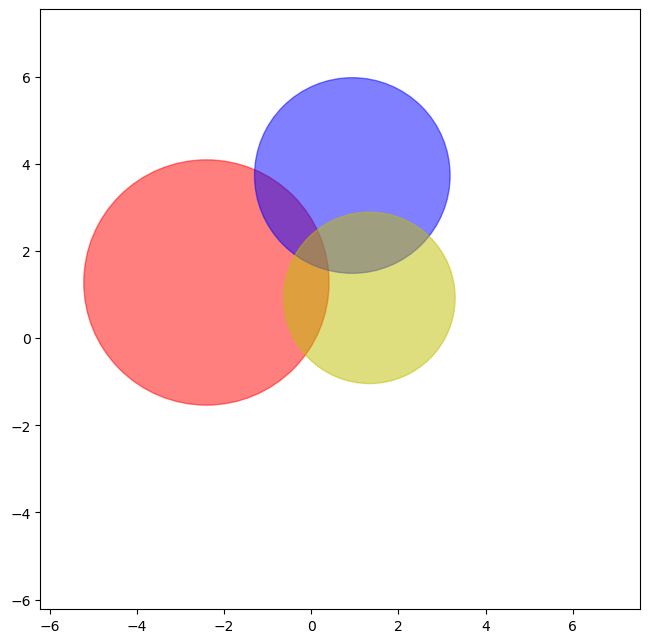

In [8]:
import matplotlib.pyplot as plt

class MyCircle(AstroEllipse):
    def __init__(self,xc,yc,radius, **args):
        super().__init__(radius,radius, xc, yc, position_angle=0, **args)


coords = []
radii= []
for i in range(3):
    coords.append([np.random.uniform(-5,5),np.random.uniform(-5,5)])
    radii.append(np.random.uniform(1,3))

coords,radii = np.array(coords),np.array(radii)

c1 = MyCircle(coords[0][0],coords[0][1],radii[0],color = 'r',alpha = 0.5)
c2 = MyCircle(coords[1][0],coords[1][1],radii[1],color = 'b',alpha = 0.5)
c3 = MyCircle(coords[2][0],coords[2][1],radii[2],color = 'y',alpha = 0.5)

minimum = np.min(coords[:,0]) if np.min(coords[:,0]) < np.min(coords[:,1]) else np.min(coords[:,1])   # selects the minimum value of all x,y center values
maximum = np.max(coords[:,0]) if np.max(coords[:,0]) > np.max(coords[:,1]) else np.max(coords[:,1])   # selects the maximum value of all x,y center values


fig = plt.figure(figsize=(2,2))
frame = fig.add_axes([0,0,3,3])

frame.add_patch(c1)
frame.add_patch(c2)
frame.add_patch(c3)

frame.set_xlim(minimum-np.max(radii)-1,maximum+np.max(radii)+1)
frame.set_ylim(minimum-np.max(radii)-1,maximum+np.max(radii)+1)

fig.show()

In [9]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

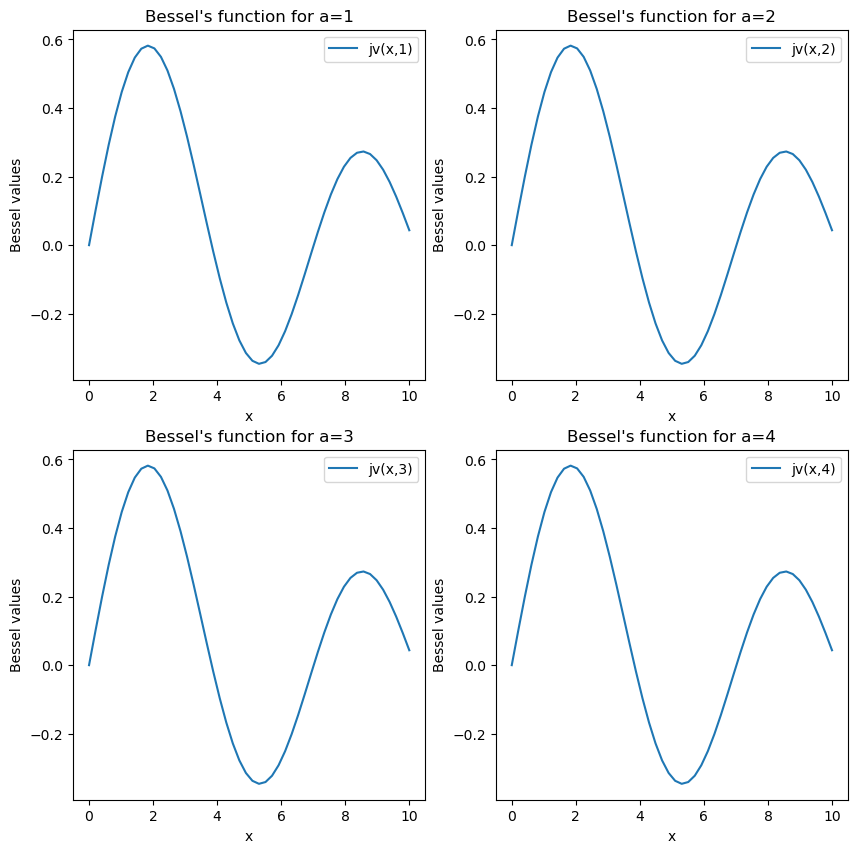

In [10]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

a = [1,2,3,4]
x = np.linspace(0,10)

fig = plt.figure(figsize=(10,10))

axes = ['a1','a2','a3','a4']
for i in range(4):
    axes[i] = fig.add_subplot(2,2,i+1)
    axes[i].plot(x,jv(a[0],x),label = f'jv(x,{i+1})')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel(f'Bessel values')
    axes[i].set_title(f'Bessel\'s function for a={i+1}')
    axes[i].legend()

fig.savefig('bessel.png',transparent=True)

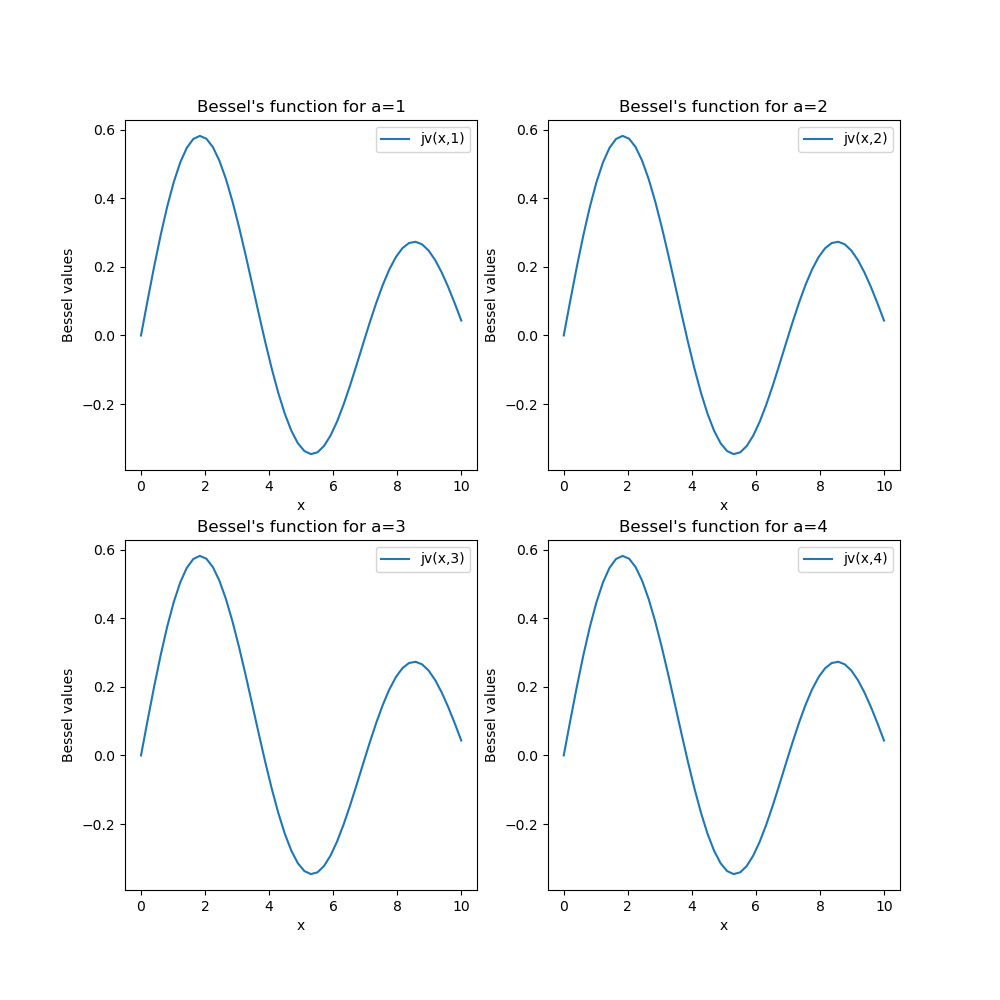

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    I believe we already discussed this in class, but your plots for Bessel are incorrect. Look again into what a you are using! <b>[0.5pt deducted from total points]</b>

In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 2.5

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

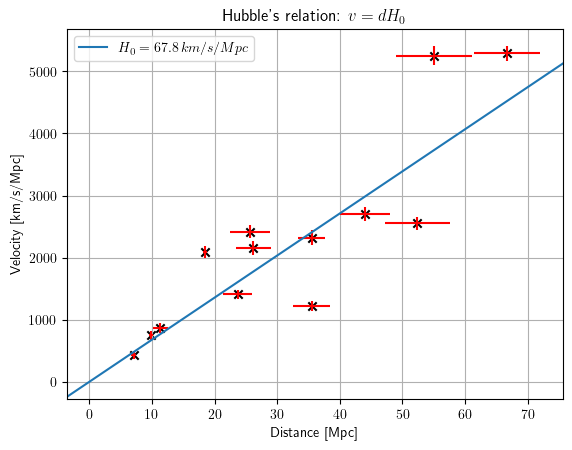

In [12]:
data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
D = data[::4]
V = data[1::4]
dD = data[2::4]
dV = data[3::4]

H0 = 67.8

plt.rc('text',usetex=True)
fig,frame = plt.subplots()
frame.set_title('Hubble\'s relation: $v=dH_0$')
frame.errorbar(D,V,yerr=dV,xerr=dD,fmt='none',ecolor = 'r')
frame.scatter(D,V,marker='x',color='black')
frame.axline(xy1=(0,0),slope=H0,label = rf'$H_0={H0}\,km/s/Mpc$')
frame.set_xlabel('Distance [Mpc]')
frame.set_ylabel('Velocity [km/s/Mpc]')
frame.grid()
frame.legend()
fig.show()

<div class="warning" style='background-color:#FFF2CF; color: #C16310; border-left: solid #EA9F27 6px; border-radius: 4px; padding:2em;'>
<span>
<b><span style='font-size: 150%;'>⚠️</span> WARNING</b><br><br>
    You did not use the OO-plotting as we want, we do not want to see plt. anymore. Instead try and import figure, subplots and show from the package <b>[1pt deducted from total points]</b>

In [13]:
# Leave unaltered
totalpoints += 2
currentpoints += 1

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [14]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 13.0.  Task Grade = 7.2
